In [3]:
import numpy as np
import matplotlib.pyplot as plt
from pandas import DataFrame, read_excel
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.ensemble import GradientBoostingClassifier
import shap
import matplotlib.pyplot as plt

In [ ]:
filename = "../DataBase/DataCollection.xlsx"
dataset: DataFrame = read_excel(filename, sheet_name="895 Records")
print(dataset.shape)

`Variables Encoding`

In [ ]:
dissolve_encoding: dict[str, int] = {"NO": 0,"YES": 1}
sample_type_enconding: dict[str, int] = {"pellet": 0, "waste": 1, "fiber": 2, "film": 3, "powder": 4}

encoding: dict[str, dict[str, int]] = {
    "Dissolution": dissolve_encoding,
    "Sample type": sample_type_enconding
}
df: DataFrame = dataset.replace(encoding, inplace=False)

`Variables Normalization`

In [77]:
df = df.drop(columns=["Polymer_ID", "Solvent_ID", "Polymer", "Solvent"])

X = df.drop(columns=["Dissolution"])
y = df["Dissolution"]


X_log = np.log1p(X)
min_max_scaler = MinMaxScaler(feature_range=(0, 1), copy=True)
X_scaled = min_max_scaler.fit_transform(X_log)

df_log_minmax = DataFrame(X_scaled, columns = X.columns, index= X.index)
df_log_minmax["Dissolution"] = y

In [78]:
target = 'Dissolution'
X = df_log_minmax.drop(columns=target)
y = df_log_minmax[target]

`Cross-Validation` - Hyperparameter Search

In [25]:
# Hyperparameters to Evaluate
param_grid = {
    'n_estimators': [10, 15, 20, 30],
    'learning_rate': [0.05, 0.1, 0.2, 0.3],
    'max_depth': [4, 5, 6, 7, 8],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 5, 10],
    'subsample': [0.8, 1.0],
    'max_features': ['sqrt', None, 'log2'],
    'loss': ['log_loss', 'exponential']
}

In [26]:
acc_val_list = []
acc_train_list = []
acc_test_list = []
recall_test_list = []
best_params_list = []


for i in range(5):  
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=i, stratify=y)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=i, stratify=y_temp)

    print(f"\n{'='*30}\nStarting Iteration {i}\n{'='*30}")
 
    grid_search = GridSearchCV(GradientBoostingClassifier(random_state=i), param_grid, cv=5, scoring='accuracy', n_jobs =-1)
    grid_search.fit(X_val, y_val)
    best_params = grid_search.best_params_
    best_params_list.append(best_params)

    model = GradientBoostingClassifier(**best_params, random_state=i)
    model.fit(X_train, y_train)

    y_val_pred = model.predict(X_val)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    acc_val = accuracy_score(y_val, y_val_pred)
    acc_train = accuracy_score(y_train, y_train_pred)
    acc_test = accuracy_score(y_test, y_test_pred)

    acc_val_list.append(acc_val)
    acc_train_list.append(acc_train)
    acc_test_list.append(acc_test)

    print(f"Best otimization:  {best_params}")
    print(f"Accuracy - Train:     {acc_train:.3f}")
    print(f"Accuracy - Validation:  {acc_val:.3f}")
    print(f"Accuracy - Test:      {acc_test:.3f}")


print("\n=== Final Results ===")
print(f"Accuracy - Train:     Mean = {np.mean(acc_train_list):.3f}, Standard Deviation = {np.std(acc_train_list):.3f}")
print(f"Accuracy - Validation: Mean = {np.mean(acc_val_list):.3f}, Standard Deviation = {np.std(acc_val_list):.3f}")
print(f"Accuracy - Test:      Mean = {np.mean(acc_test_list):.3f}, Standard Deviation = {np.std(acc_test_list):.3f}")


Starting Iteration 0


Best otimization:  {'learning_rate': 0.3, 'loss': 'log_loss', 'max_depth': 5, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 20, 'subsample': 0.8}
Accuracy - Train:     0.984
Accuracy - Validation:  0.896
Accuracy - Test:      0.933

Starting Iteration 1
Best otimization:  {'learning_rate': 0.3, 'loss': 'log_loss', 'max_depth': 4, 'max_features': None, 'min_samples_leaf': 10, 'min_samples_split': 2, 'n_estimators': 30, 'subsample': 0.8}
Accuracy - Train:     0.971
Accuracy - Validation:  0.903
Accuracy - Test:      0.911

Starting Iteration 2
Best otimization:  {'learning_rate': 0.2, 'loss': 'log_loss', 'max_depth': 7, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 20, 'subsample': 0.8}
Accuracy - Train:     0.978
Accuracy - Validation:  0.903
Accuracy - Test:      0.881

Starting Iteration 3
Best otimization:  {'learning_rate': 0.2, 'loss': 'exponential', 'max_depth': 6, 'max_features': 'sqrt', 'min_samples_

`Cross-Validation` - Manual Fine-Tunning

In [79]:
#random_state = np.random.randint(0, 2**32)
#print(random_state)
random_state = 1764725350


In [80]:
# Hyperparameters to Evaluate across 5 different data splits
param_grid = {
    'learning_rate': 0.3,
    'loss': 'log_loss',
    'max_depth': 4,
    'max_features': 'sqrt',
    'min_samples_leaf': 10,
    'min_samples_split': 2,
    'n_estimators': 30,
    'subsample': 0.5,
}

In [81]:
acc_val_list = []
acc_train_list = []
acc_test_list = []
recall_test_list = []
best_params_list = []

for i in range(5): 
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=i, stratify=y)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=i, stratify=y_temp)

    print(f"\n{'='*30}\nStarting Iteration {i+1}\n{'='*30}")

    gb_model = GradientBoostingClassifier(**param_grid, random_state = random_state)
    gb_model.fit(X_train, y_train)

    y_val_pred = gb_model.predict(X_val)
    y_train_pred = gb_model.predict(X_train)
    y_test_pred = gb_model.predict(X_test)

    acc_val = accuracy_score(y_val, y_val_pred)
    acc_train = accuracy_score(y_train, y_train_pred)
    acc_test = accuracy_score(y_test, y_test_pred)

    acc_val_list.append(acc_val)
    acc_train_list.append(acc_train)
    acc_test_list.append(acc_test)

    print(f"Running parameters:  {param_grid}")
    print(f"Accuracy - Train:     {acc_train:.4f}")
    print(f"Accuracy - Validation:  {acc_val:.4f}")
    print(f"Accuracy - Test:      {acc_test:.4f}")


print("\n=== Final Results ===")
print(f"Accuracy - Train:     Mean = {np.mean(acc_train_list):.4f}, Standard Deviation = {np.std(acc_train_list):.4f}")
print(f"Accuracy - Validation: Mean = {np.mean(acc_val_list):.4f}, Standard Deviation = {np.std(acc_val_list):.4f}")
print(f"Accuracy - Test:      Mean = {np.mean(acc_test_list):.4f}, Standard Deviation = {np.std(acc_test_list):.4f}")


Starting Iteration 1
Running parameters:  {'learning_rate': 0.3, 'loss': 'log_loss', 'max_depth': 4, 'max_features': 'sqrt', 'min_samples_leaf': 10, 'min_samples_split': 2, 'n_estimators': 30, 'subsample': 0.5}
Accuracy - Train:     0.9201
Accuracy - Validation:  0.8731
Accuracy - Test:      0.9407

Starting Iteration 2
Running parameters:  {'learning_rate': 0.3, 'loss': 'log_loss', 'max_depth': 4, 'max_features': 'sqrt', 'min_samples_leaf': 10, 'min_samples_split': 2, 'n_estimators': 30, 'subsample': 0.5}
Accuracy - Train:     0.9265
Accuracy - Validation:  0.8507
Accuracy - Test:      0.9037

Starting Iteration 3
Running parameters:  {'learning_rate': 0.3, 'loss': 'log_loss', 'max_depth': 4, 'max_features': 'sqrt', 'min_samples_leaf': 10, 'min_samples_split': 2, 'n_estimators': 30, 'subsample': 0.5}
Accuracy - Train:     0.9281
Accuracy - Validation:  0.9030
Accuracy - Test:      0.8815

Starting Iteration 4
Running parameters:  {'learning_rate': 0.3, 'loss': 'log_loss', 'max_depth'

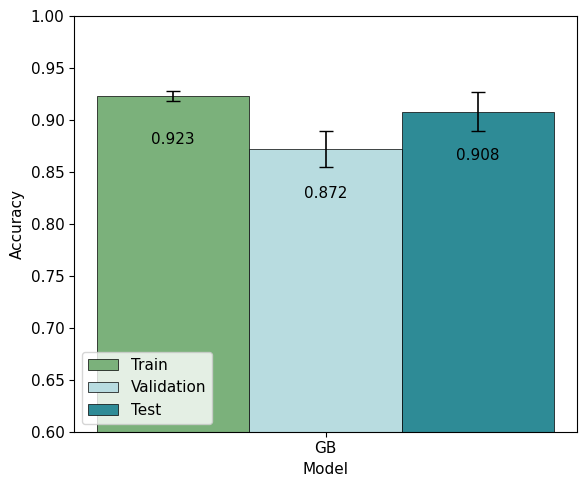

In [ ]:
means = [0.9230, 0.8716, 0.9081]
stds = [0.0047, 0.0173, 0.0191]
labels = ['Train', 'Validation', 'Test']
colors = ['#7BB17B', '#B8DCE0', '#2E8B96']

plt.rcParams.update({'font.size': 11})
x_center = 0
width = 0.25
positions = [x_center - width, x_center, x_center + width]

fig, ax = plt.subplots(figsize=(6, 5))

bars = ax.bar(positions, means, width, yerr=stds, color=colors,
              edgecolor='black', linewidth=0.5,
              capsize=5, error_kw={'elinewidth': 1.2, 'ecolor': 'black'})


for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2, mean - 0.035,
            f'{mean:.3f}', ha='center', va='top', fontsize=11, color='black')

ax.set_ylim(0.60, 1.00)
ax.set_yticks(np.arange(0.60, 1.01, 0.05))
ax.set_ylabel('Accuracy', fontsize=11)
ax.set_xlabel('Model', fontsize=11)
ax.set_xticks([x_center])
ax.set_xticklabels(['GB'], fontsize=11)
ax.tick_params(axis='both', labelsize=11)

legend_handles = [plt.Rectangle((0, 0), 1, 1, color=c, ec='black', lw=0.5) for c in colors]
ax.legend(legend_handles, labels, loc='lower left', frameon=True, fontsize=11)

ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)

plt.tight_layout()
plt.show()

`XAI SHAP` - BeeSwarm Plot

In [82]:
gb_model.fit(X, y)
background = shap.sample(X)
explainer = shap.TreeExplainer(gb_model, data=background, model_output="probability")
shap_values = explainer(X)

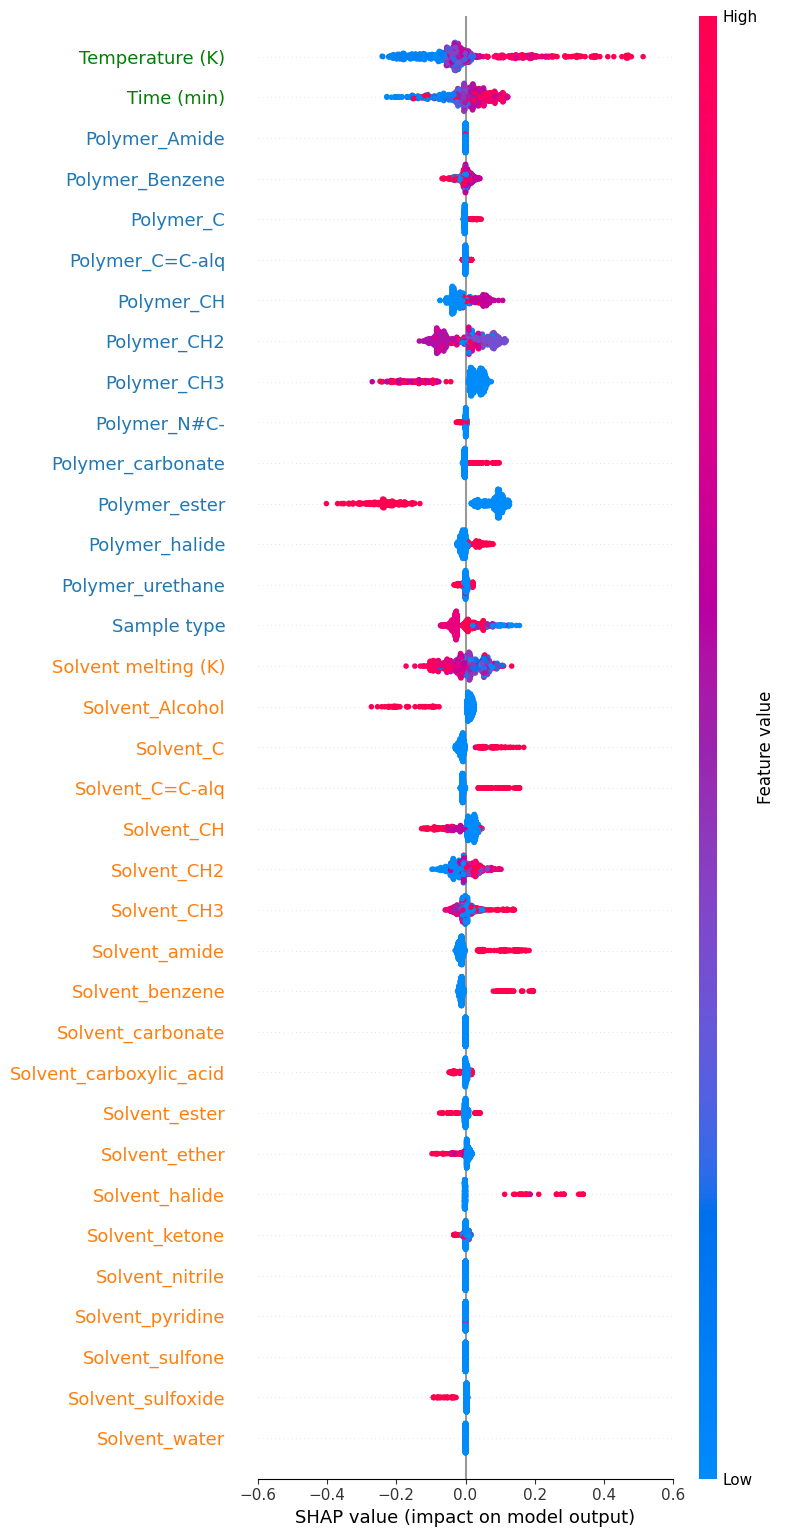

In [ ]:
feature_order = [
    'Temperature (K)', 'Time (min)',
    'Polymer_Amide', 'Polymer_Benzene', 'Polymer_C', 'Polymer_C=C-alq',
    'Polymer_CH', 'Polymer_CH2', 'Polymer_CH3', 'Polymer_N#C-',
    'Polymer_carbonate', 'Polymer_ester', 'Polymer_halide', 'Polymer_urethane',
    'Sample type',
    'Solvent melting (K)',
    'Solvent_Alcohol', 'Solvent_C', 'Solvent_C=C-alq', 'Solvent_CH',
    'Solvent_CH2', 'Solvent_CH3', 'Solvent_amide', 'Solvent_benzene',
    'Solvent_carbonate', 'Solvent_carboxylic_acid', 'Solvent_ester',
    'Solvent_ether', 'Solvent_halide', 'Solvent_ketone', 'Solvent_nitrile',
    'Solvent_pyridine', 'Solvent_sulfone', 'Solvent_sulfoxide', 'Solvent_water',
]

sv = shap_values[:, feature_order]

plt.figure(figsize=(10, 12))
shap.plots.beeswarm(
    sv,
    max_display=len(feature_order),
    order=np.arange(len(feature_order)),               
    show=False,
)

ax = plt.gca()
ax.set_xlim(-0.6, 0.6)                    

def color_feature(name):
    if name in ('Temperature (K)', 'Time (min)'): return 'green'
    if name.startswith('Polymer') or name == 'Sample type': return 'tab:blue'
    if name.startswith('Solvent'): return 'tab:orange'

for label in ax.get_yticklabels():
    label.set_color(color_feature(label.get_text()))

plt.tight_layout()
plt.show()

`XAI SHAP` - Feature Relative Importance Plot

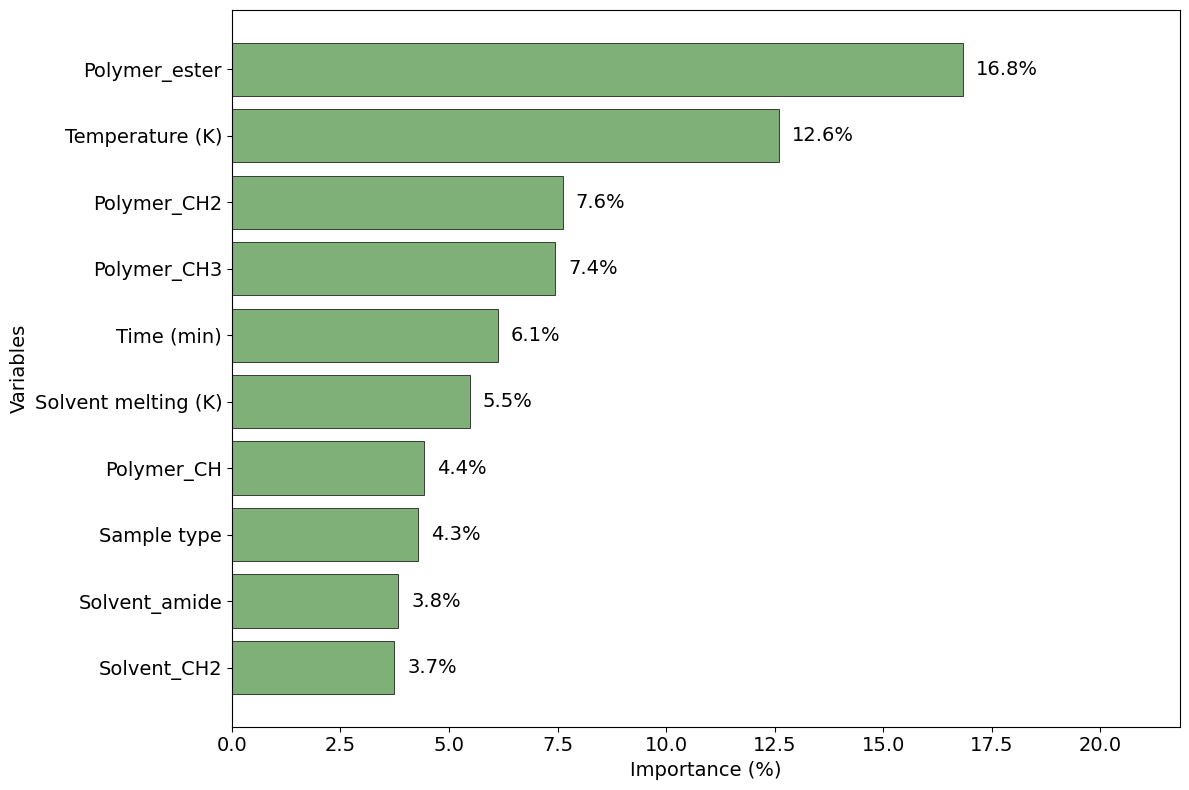

In [ ]:
max_display = 10
mean_shap = np.mean(np.abs(shap_values.values), axis=0)
importance_features_percentage = (mean_shap / mean_shap.sum()) * 100

feature_names = shap_values.feature_names
data = sorted(zip(feature_names, importance_features_percentage), key=lambda x: x[1], reverse=False)
data = data[-max_display:]
sorted_names, sorted_values = zip(*data)

fig, ax = plt.subplots(figsize=(12, 8))

bar_color = '#7eb078' 
bars = ax.barh(sorted_names, sorted_values, color=bar_color, edgecolor='black', linewidth=0.5)

for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.3, bar.get_y() + bar.get_height()/2, 
            f'{width:.1f}%', va='center', fontsize=14)
ax.tick_params(axis='both', labelsize=14)
ax.set_xlabel("Importance (%)", fontsize=14)
ax.set_ylabel("Variables", fontsize=14)
ax.set_xlim(0, max(sorted_values) + 5)  

plt.tight_layout()
plt.show()